# Model Evaluation Notebook
Load a trained model checkpoint and visualize predictions on validation data (Site B)

## 1. Configuration
Update these settings to match your model and data paths

In [1]:
model_number = 11  # Change this to switch between different model configurations
model_name = None
is_causal = None


if model_number == 1:
    model_name = "LSTM"
    # Best model from basic regression notebook run
    # NMAE(mean): 2.00
    MODEL_CHECKPOINT = "../notebooks/wandb/basic_regression_notebook_run/best_model.pt"
    MODEL_CONFIG = {
        'input_size': 37,      # Number of features
        'hidden_size': 64,     # Hidden layer size from best run
        'num_layers': 2,       # Number of LSTM layers from best run
        'output_size': 1,      # Output size
        'dropout': 0.3,        # Dropout from best run
        'sequence_length': 12  # Sequence length
    }
elif model_number == 2:
    model_name = "LSTM"
    # Model run try with penalized loss for predictions on 0
    # NMAE(mean): 1.85
    MODEL_CHECKPOINT = "../notebooks/wandb/run-20251120_174141-10m6a29w/files/best_model.pt"
    MODEL_CONFIG = {
        'input_size': 37,      # Number of features
        'hidden_size': 64,     # Hidden layer size from best run
        'num_layers': 2,       # Number of LSTM layers from best run
        'output_size': 1,      # Output size
        'dropout': 0.3,        # Dropout from best run
        'sequence_length': 12  # Sequence length
    }
elif model_number == 3:
    model_name = "LSTM"
    # Model run from training only on events
    # NMAE(mean): 2.05
    MODEL_CHECKPOINT = "../notebooks/wandb/run-20251127_204031-x49xw25h/files/best_model.pt"
    MODEL_CONFIG = {
        'input_size': 37,      # Number of features
        'hidden_size': 64,     # Hidden layer size from best run
        'num_layers': 2,       # Number of LSTM layers from best run
        'output_size': 1,      # Output size
        'dropout': 0.4,        # Dropout from best run
        'sequence_length': 48  # Sequence length
    }
elif model_number == 4:
    model_name = "LSTM"
    # Model run from training only on events with different hyperparameters
    # NMAE(mean): 1.68
    MODEL_CHECKPOINT = "../notebooks/wandb/run-20251128_133531-utbdaq53/files/best_model.pt"
    MODEL_CONFIG = {
        'input_size': 37,      # Number of features
        'hidden_size': 64,    # Hidden layer size from best run
        'num_layers': 4,       # Number of LSTM layers from best run
        'output_size': 1,      # Output size
        'dropout': 0.15816372968738704,        # Dropout from best run
        'sequence_length': 36  # Sequence length
    }
elif model_number == 5:
    model_name = "LSTM"
    # Model run from refactored notebook script on penalized loss
    # NMAE(mean): 2.12
    MODEL_CHECKPOINT = "../notebooks/wandb/run-20251201_000347-w77qpxgb/files/best_model.pt"
    MODEL_CONFIG = {
        'input_size': 37,      # Number of features
        'hidden_size': 64,    # Hidden layer size from best run
        'num_layers': 2,       # Number of LSTM layers from best run
        'output_size': 1,      # Output size
        'dropout': 0.3,        # Dropout from best run
        'sequence_length': 12  # Sequence length
    }
elif model_number == 6:
    model_name = "TCN"
    is_causal = True
    # TCN model from (short test) sweep with penalized loss
    # NMAE(mean): 1.57
    MODEL_CHECKPOINT = "../notebooks/wandb/run-20251202_220327-lj7pg1h5/files/best_model.pt"
    MODEL_CONFIG = {
        'input_size': 37,
        'out_channels': 32,
        'num_blocks': 4,
        'kernel_size': 7,
        'dilation_base': 1,
        'dropout': 0.5295091416471653,
        'output_size': 1,
        'sequence_length': 24
    }
elif model_number == 7:
    model_name = "TCN"
    is_causal = True
    # TCN model from longer sweep with penalized loss
    # NMAE(mean): 1.60
    MODEL_CHECKPOINT = "../notebooks/wandb/run-20251205_214847-shyr1ytk/files/best_model.pt"
    MODEL_CONFIG = {
        'input_size': 37,
        'out_channels': 256,
        'num_blocks': 8,
        'kernel_size': 7,
        'dilation_base': 1,
        'dropout': 0.4604455063743994,
        'output_size': 1,
        'sequence_length': 12
    }
elif model_number == 8:
    model_name = "ModernTCN"
    is_causal = True
    # Modern TCN model from notebook with penalized loss
    # NMAE(mean): 1.73
    MODEL_CHECKPOINT = "../notebooks/wandb/run-20251204_182409-tsff1566/files/best_model.pt"
    MODEL_CONFIG = {
        'input_size': 37,
        'out_channels': 64,
        'num_blocks': 4,
        'kernel_size': 5,
        'dropout': 0.2,
        'output_size': 1,
        'sequence_length': 48
    }
elif model_number == 9:
    model_name = "ModernTCN"
    is_causal = True
    # Modern TCN model from sweep with penalized loss
    # NMAE(mean): 1.75
    MODEL_CHECKPOINT = "../notebooks/wandb/run-20251204_193530-2m724h96/files/best_model.pt"
    MODEL_CONFIG = {
        'input_size': 37,
        'out_channels': 48,
        'num_blocks': 4,
        'kernel_size': 7,
        'dropout': 0.24831183086705264,
        'output_size': 1,
        'sequence_length': 96
    }
elif model_number == 10:
    model_name = "Transformer"
    # Transformer from sweep with penalized loss
    # NMAE(mean): 1.67
    MODEL_CHECKPOINT = "../notebooks/wandb/run-20251205_093831-er38yvl6/files/best_model.pt"
    MODEL_CONFIG = {
        'input_size': 37,
        'd_model': 256,
        'nhead': 2,
        'num_layers': 4,
        'dropout': 0.046455625915031995,
        'output_size': 1,
        'max_seq_len': 500,
        'sequence_length': 48
    }
elif model_number == 11:
    model_name = "Autoformer"
    # Autoformer from sweep with penalized loss
    # NMAE(mean): 1.64
    MODEL_CHECKPOINT = "../notebooks/wandb/run-20251207_215841-3jlrrzpq/files/best_model.pt"
    MODEL_CONFIG = {
        'input_size': 37,
        'd_model': 128,
        'nhead': 8,
        'num_layers': 3,
        'dropout': 0.1465924998070578,
        'output_size': 1,
        'sequence_length': 48,
        'decomp_kernel': 49
    }


# Data paths
DATA_PATH = "C:/Github_FabianDubach/aicomp-flextrack/data/regression/"

# Constants
ENTRIES_PER_DAY = 53  # 15 min intervals from 6:00 to 19:00

## 2. Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
import sys
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette('husl')

# Add path for comp_metrics
import sys
sys.path.append("../src/evaluation")
from comp_metrics import evaluate_all_metrics

# Add path for model checkpoints
sys.path.append("../AICOMP-FlexTrack")

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 3. Model Definition
LSTM

In [3]:
if model_name == "LSTM":

    class SimpleRNN(nn.Module):
        """LSTM model for regression"""
        def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.3):
            super(SimpleRNN, self).__init__()
            self.hidden_size = hidden_size
            self.num_layers = num_layers
            
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
            self.dropout = nn.Dropout(dropout)
            self.fc = nn.Linear(hidden_size, output_size)
        
        def forward(self, x):
            h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
            c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
            
            out, _ = self.lstm(x, (h0, c0))
            out = out[:, -1, :]
            out = self.dropout(out)
            out = self.fc(out)
            return out

    print("✅ Model class defined")

TCN

In [4]:
if model_name == "TCN":

    class Chomp1d(nn.Module):
        """Remove extra padding from causal conv to keep output length same as input"""
        def __init__(self, chomp_size):
            super().__init__()
            self.chomp_size = chomp_size

        def forward(self, x):
            return x[:, :, :-self.chomp_size].contiguous()

    class TemporalBlock(nn.Module):
        def __init__(self, in_channels, out_channels, kernel_size, stride, dilation, padding, dropout, causal):
            super().__init__()
            # Replace weight_norm with spectral_norm
            self.conv1 = spectral_norm(nn.Conv1d(in_channels, out_channels, kernel_size,
                                                stride=stride, padding=padding, dilation=dilation))
            if causal:
                self.chomp1 = Chomp1d(padding)
            else:
                self.chomp1 = nn.Identity()
            self.relu1 = nn.ReLU()
            self.dropout1 = nn.Dropout(dropout)

            self.conv2 = spectral_norm(nn.Conv1d(out_channels, out_channels, kernel_size,
                                                stride=stride, padding=padding, dilation=dilation))
            if causal:
                self.chomp2 = Chomp1d(padding)
            else:
                self.chomp2 = nn.Identity()
            self.relu2 = nn.ReLU()
            self.dropout2 = nn.Dropout(dropout)

            self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                    self.conv2, self.chomp2, self.relu2, self.dropout2)
            self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
            self.relu = nn.ReLU()

        def forward(self, x):
            out = self.net(x)
            res = x if self.downsample is None else self.downsample(x)
            return self.relu(out + res)

    class TCN(nn.Module):
        def __init__(self, input_size, output_size, num_channels, kernel_size=2, dropout=0.2):
            super().__init__()
            layers = []
            num_levels = len(num_channels)
            for i in range(num_levels):
                in_ch = input_size if i == 0 else num_channels[i-1]
                out_ch = num_channels[i]
                dilation = 2**i
                
                if is_causal:
                    padding_value = (kernel_size - 1) * dilation
                else:
                    # symmetric "same" padding for non-causal
                    padding_value = ((kernel_size - 1) * dilation) // 2

                layers.append(
                    TemporalBlock(
                        in_ch, out_ch, kernel_size,
                        stride=1, dilation=dilation,
                        padding=padding_value,
                        dropout=dropout,
                        causal=is_causal
                    )
                )

            self.network = nn.Sequential(*layers)
            self.fc = nn.Linear(num_channels[-1], output_size)

        def forward(self, x):
            # TCN expects (batch, channels, seq_len)
            x = x.transpose(1, 2)  # (B, seq_len, features) → (B, features, seq_len)
            y = self.network(x)
            y = y[:, :, -1]        # take last time step
            y = self.fc(y)
            return y

ModernTCN

In [5]:
if model_name == "ModernTCN":
    
    class TemporalBlockDS(nn.Module):
        def __init__(self, in_channels, out_channels, kernel_size, dilation,
                    dropout, causal=False):
            super().__init__()

            padding = (kernel_size - 1) * dilation
            if not causal:
                padding //= 2

            self.causal = causal
            self.pad_left = padding
            self.pad_right = 0 if causal else padding

            # depthwise
            self.depthwise = nn.Conv1d(
                in_channels,
                in_channels,
                kernel_size,
                padding=0,
                dilation=dilation,
                groups=in_channels,
                bias=False
            )

            # pointwise
            self.pointwise = nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False
            )
            
            self.norm1 = nn.BatchNorm1d(out_channels)

            self.act = nn.GELU()
            self.dropout = nn.Dropout(dropout)

            # residual
            self.residual = nn.Conv1d(in_channels, out_channels, 1) \
                if in_channels != out_channels else nn.Identity()

        def forward(self, x):
            # padding
            x_pad = F.pad(x, (self.pad_left, self.pad_right))

            y = self.depthwise(x_pad)
            y = self.pointwise(y)
            y = self.norm1(y)
            y = self.act(y)
            y = self.dropout(y)

            return y + self.residual(x)
        
    class ModernTCN(nn.Module):
        """
        Modern TCN with depthwise separable dilated convs, residuals, RevIN optional,
        and configurable readout. Suitable for long-range predictions.
        Input: (B, seq_len, features)
        Output: (B, out_dim) -- by default out_dim=1
        """
        def __init__(self, input_size, seq_len, out_dim=1, hidden_dim=128, num_layers=6,
                    kernel_size=3, dropout=0.1, causal=True,
                    readout='last', channel_growth=True):
            """
            readout: 'last' (use last timestep features), 'global_avg' (avg over time),
                    or 'flatten' (flatten entire representation -- use with caution)
            channel_growth: if True, doubles channels every 2 layers until hidden_dim
                            (helps increase capacity progressively)
            """
            super().__init__()
            self.input_size = input_size
            self.seq_len = seq_len
            self.out_dim = out_dim
            self.hidden_dim = hidden_dim
            self.num_layers = num_layers
            self.kernel_size = kernel_size
            self.dropout = dropout
            self.causal = causal
            self.readout = readout

            # Add this line BEFORE the loop
            self.input_projection = nn.Conv1d(input_size, hidden_dim, kernel_size=1)

            layers = []
            in_ch = hidden_dim  # Now we start with hidden_dim channels (e.g., 128)
            for i in range(num_layers):
                out_ch = hidden_dim  # Just keep it constant - no complex growth logic
                
                dilation = 2 ** i
                block = TemporalBlockDS(in_ch, out_ch,
                                        kernel_size=kernel_size,
                                        dilation=dilation,
                                        dropout=dropout,
                                        causal=causal)
                layers.append(block)
                in_ch = out_ch

            self.tcn = nn.Sequential(*layers)

            # readout / head
            if readout == 'last':
                self.head = nn.Sequential(
                    nn.Linear(in_ch, in_ch // 2 if in_ch >= 2 else 1),
                    nn.GELU(),
                    nn.Dropout(dropout),
                    nn.Linear(in_ch // 2 if in_ch >= 2 else 1, out_dim)
                )
            elif readout == 'global_avg':
                # we will GlobalAvg over time -> shape (B, C)
                self.head = nn.Sequential(
                    nn.Linear(in_ch, in_ch // 2 if in_ch >= 2 else 1),
                    nn.GELU(),
                    nn.Dropout(dropout),
                    nn.Linear(in_ch // 2 if in_ch >= 2 else 1, out_dim)
                )
            elif readout == 'flatten':
                # flatten (C * T) -> out_dim (be mindful of params)
                self.head = nn.Sequential(
                    nn.Linear(in_ch * seq_len, hidden_dim),
                    nn.GELU(),
                    nn.Dropout(dropout),
                    nn.Linear(hidden_dim, out_dim)
                )
            else:
                raise ValueError("readout must be 'last', 'global_avg' or 'flatten'")

        def forward(self, x):
            # x: (B, seq_len, features)
            B, T, C = x.shape
            assert C == self.input_size, f"Expected input feature dim {self.input_size}, got {C}"

            # conv expects (B, C, T)
            x = x.transpose(1, 2)

            x = self.input_projection(x)

            # TCN forward
            y = self.tcn(x)   # (B, channels, T)

            # readout
            if self.readout == 'last':
                y = y[:, :, -1]           # (B, channels)
                out = self.head(y)       # (B, out_dim)
            elif self.readout == 'global_avg':
                y = torch.mean(y, dim=2)  # (B, channels)
                out = self.head(y)
            else:  # flatten
                out = y.view(B, -1)
                out = self.head(out)

            # NOTE: We do NOT denormalize predictions automatically, because RevIN
            # was applied to the input features (not the target). If you used RevIN
            # to normalize the target, you should call revin.denorm on a shaped tensor.
            return out

    print("✅ Model class defined")

Transformer

In [6]:
if model_name == "Transformer":    

    class TransformerRegressor(nn.Module):
        def __init__(self, input_size, d_model, nhead, num_layers, output_size, dropout=0.1, max_seq_len=500):
            super(TransformerRegressor, self).__init__()
            self.d_model = d_model
            
            # Input projection
            self.input_projection = nn.Linear(input_size, d_model)
            
            # FIXED: Dynamic positional encoding with larger max length
            self.pos_encoder = nn.Parameter(torch.randn(1, max_seq_len, d_model))
            
            # Transformer encoder
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout,
                batch_first=True
            )
            self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            
            # Output layers
            self.dropout = nn.Dropout(dropout)
            self.fc = nn.Linear(d_model, output_size)
        
        def forward(self, x):
            # x shape: (batch, seq_len, input_size)
            seq_len = x.size(1)
            
            # Project input to d_model dimension
            x = self.input_projection(x)  # (batch, seq_len, d_model)
            
            # Add positional encoding (now safely handles any seq_len <= max_seq_len)
            x = x + self.pos_encoder[:, :seq_len, :]
            
            # Transformer encoding
            x = self.transformer_encoder(x)  # (batch, seq_len, d_model)
            
            # Use the last token's output for prediction
            x = x[:, -1, :]  # (batch, d_model)
            
            # Dropout and final prediction
            x = self.dropout(x)
            x = self.fc(x)
            return x
        
        print("✅ Model class defined")

Autoformer

In [7]:
if model_name == "Autoformer":    

    class MovingAvg(nn.Module):
        """Moving average block for series decomposition"""
        def __init__(self, kernel_size, stride=1):
            super(MovingAvg, self).__init__()
            self.kernel_size = kernel_size
            self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

        def forward(self, x):
            # x: (batch, seq_len, channels)
            # Padding on both ends
            front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
            end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
            x = torch.cat([front, x, end], dim=1)
            x = self.avg(x.permute(0, 2, 1))  # (batch, channels, seq_len)
            x = x.permute(0, 2, 1)  # (batch, seq_len, channels)
            return x


    class SeriesDecomp(nn.Module):
        """Series decomposition block"""
        def __init__(self, kernel_size):
            super(SeriesDecomp, self).__init__()
            self.moving_avg = MovingAvg(kernel_size, stride=1)

        def forward(self, x):
            moving_mean = self.moving_avg(x)
            res = x - moving_mean
            return res, moving_mean


    class AutoCorrelation(nn.Module):
        """Fast vectorized Auto-Correlation mechanism"""
        def __init__(self, d_model, n_heads, dropout=0.1, top_k=5):
            super(AutoCorrelation, self).__init__()
            self.d_model = d_model
            self.n_heads = n_heads
            self.d_k = d_model // n_heads
            self.top_k = top_k
            
            self.query_projection = nn.Linear(d_model, d_model)
            self.key_projection = nn.Linear(d_model, d_model)
            self.value_projection = nn.Linear(d_model, d_model)
            self.out_projection = nn.Linear(d_model, d_model)
            self.dropout = nn.Dropout(dropout)

        def forward(self, queries, keys, values):
            B, L, _ = queries.shape
            S = keys.shape[1]
            H = self.n_heads

            queries = self.query_projection(queries).view(B, L, H, self.d_k)
            keys = self.key_projection(keys).view(B, S, H, self.d_k)
            values = self.value_projection(values).view(B, S, H, self.d_k)

            # Reshape to (B, H, L, d_k)
            queries = queries.permute(0, 2, 1, 3)
            keys = keys.permute(0, 2, 1, 3)
            values = values.permute(0, 2, 1, 3)
            
            # ============================================================================
            # OPTION 1: Standard Attention (Recommended - Most Stable)
            # ============================================================================
            
            # Compute similarity scores (dot product attention)
            # queries: (B, H, L, d_k), keys: (B, H, L, d_k)
            scores = torch.matmul(queries, keys.transpose(-2, -1)) / (self.d_k ** 0.5)  # (B, H, L, L)
            
            # Apply causal mask
            causal_mask = torch.triu(
                torch.ones(L, L, device=queries.device, dtype=torch.bool), 
                diagonal=1
            )  # Upper triangular = future positions
            scores = scores.masked_fill(causal_mask, float('-inf'))
            
            # Compute attention weights
            attn_weights = F.softmax(scores, dim=-1)  # (B, H, L, L)
            
            # Handle NaN from softmax (when entire row is -inf, shouldn't happen with causal mask)
            attn_weights = torch.nan_to_num(attn_weights, nan=0.0)
            
            # Apply dropout to attention weights
            attn_weights = self.dropout(attn_weights)
            
            # Apply attention to values
            out = torch.matmul(attn_weights, values)  # (B, H, L, d_k)
            
            # Reshape back to (B, L, d_model)
            out = out.permute(0, 2, 1, 3).reshape(B, L, -1)
            return self.out_projection(out)


    class AutoformerEncoderLayer(nn.Module):
        """Autoformer Encoder Layer"""
        def __init__(self, d_model, n_heads, d_ff, dropout=0.1, decomp_kernel=25):
            super(AutoformerEncoderLayer, self).__init__()
            
            self.auto_correlation = AutoCorrelation(d_model, n_heads, dropout)
            self.decomp1 = SeriesDecomp(decomp_kernel)
            self.decomp2 = SeriesDecomp(decomp_kernel)
            
            self.conv1 = nn.Conv1d(d_model, d_ff, kernel_size=1)
            self.conv2 = nn.Conv1d(d_ff, d_model, kernel_size=1)
            self.activation = nn.GELU()
            self.dropout = nn.Dropout(dropout)

        def forward(self, x):
            # Auto-correlation
            new_x = self.auto_correlation(x, x, x)
            x = x + self.dropout(new_x)
            x, _ = self.decomp1(x)
            
            # Feed-forward
            y = x.transpose(1, 2)
            y = self.dropout(self.activation(self.conv1(y)))
            y = self.dropout(self.conv2(y))
            y = y.transpose(1, 2)
            
            res, _ = self.decomp2(x + y)
            return res


    class AutoformerRegressor(nn.Module):
        """Autoformer model for regression"""
        def __init__(self, input_size, d_model, nhead, num_layers, output_size, 
                    dropout=0.1, decomp_kernel=25, max_seq_len=500):
            super(AutoformerRegressor, self).__init__()
            self.d_model = d_model
            
            # Input projection
            self.input_projection = nn.Linear(input_size, d_model)
            
            # Positional encoding
            self.pos_encoder = nn.Parameter(torch.randn(1, max_seq_len, d_model))
            
            # Initial decomposition
            self.decomp = SeriesDecomp(decomp_kernel)
            
            # Autoformer encoder layers (convert num_layers to int)
            self.encoder_layers = nn.ModuleList([
                AutoformerEncoderLayer(d_model, nhead, d_model * 4, dropout, decomp_kernel)
                for _ in range(int(num_layers))
            ])
            
            # Output layers
            self.dropout = nn.Dropout(dropout)
            self.fc = nn.Linear(d_model, output_size)
            
            # Trend projection
            self.trend_projection = nn.Linear(d_model, output_size)

        def forward(self, x):
            # x shape: (batch, seq_len, input_size)
            seq_len = x.size(1)
            
            # Project input to d_model dimension
            x = self.input_projection(x)  # (batch, seq_len, d_model)
            
            # Add positional encoding
            x = x + self.pos_encoder[:, :seq_len, :]
            
            # Initial decomposition
            seasonal, trend = self.decomp(x)
            
            # Encoder layers (process seasonal component)
            for layer in self.encoder_layers:
                seasonal = layer(seasonal)
            
            # Use the last token's output for prediction
            seasonal_out = seasonal[:, -1, :]  # (batch, d_model)
            trend_out = trend[:, -1, :]  # (batch, d_model)
            
            # Combine seasonal and trend
            seasonal_pred = self.fc(self.dropout(seasonal_out))
            trend_pred = self.trend_projection(trend_out)
            
            output = seasonal_pred + trend_pred
            return output

## 4. Data Processing Functions

In [8]:
def add_time_features(df):
    """Add temporal features to the dataframe"""
    australian_holidays = holidays.AU()
    
    df['Timestamp_Local'] = pd.to_datetime(df['Timestamp_Local'])
    df['hour'] = df['Timestamp_Local'].dt.hour
    df['minute'] = df['Timestamp_Local'].dt.minute
    df['month'] = df['Timestamp_Local'].dt.month
    df['day_of_week'] = df['Timestamp_Local'].dt.dayofweek
    df['is_weekend'] = df['Timestamp_Local'].dt.dayofweek >= 5
    df['is_holiday'] = df['Timestamp_Local'].dt.date.apply(lambda x: x in australian_holidays)
    return df


def engineer_features(df):
    """Complete feature engineering pipeline"""
    df = add_time_features(df)
    
    # Remove night entries (6 AM to 7 PM only)
    df = df[
        ((df['hour'] > 6) & (df['hour'] < 19)) |
        ((df['hour'] == 6) & (df['minute'] >= 0)) |
        ((df['hour'] == 19) & (df['minute'] == 0))
    ].copy()
    
    # Cyclic encoding for month
    df['month_sin'] = np.sin(2 * np.pi * (df['month'] / 12))
    df['month_cos'] = np.cos(2 * np.pi * (df['month'] / 12))
    df.drop(columns=['month'], inplace=True)
    
    # Difference features
    df['Building_Power_kW_diff_15min'] = df.groupby('Site')['Building_Power_kW'].diff(1)
    df['Building_Power_kW_diff_1h'] = df.groupby('Site')['Building_Power_kW'].diff(4)
    df['Building_Power_kW_diff_1d'] = df.groupby('Site')['Building_Power_kW'].diff(ENTRIES_PER_DAY)
    df['Dry_Bulb_Temperature_C_diff_15min'] = df.groupby('Site')['Dry_Bulb_Temperature_C'].diff(1)
    df['Global_Horizontal_Radiation_W/m2_diff_15min'] = df.groupby('Site')['Global_Horizontal_Radiation_W/m2'].diff(1)
    
    # Rolling statistics
    group = df.groupby('Site')['Building_Power_kW']
    df['Building_Power_kW_rolling_mean_1h'] = group.rolling(4).mean().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_mean_2h'] = group.rolling(8).mean().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_mean_1d'] = group.rolling(ENTRIES_PER_DAY).mean().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_std_1h'] = group.rolling(4).std().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_std_2h'] = group.rolling(8).std().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_std_1d'] = group.rolling(ENTRIES_PER_DAY).std().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_min_1h'] = group.rolling(4).min().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_min_2h'] = group.rolling(8).min().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_max_1h'] = group.rolling(4).max().reset_index(level=0, drop=True)
    df['Building_Power_kW_rolling_max_2h'] = group.rolling(8).max().reset_index(level=0, drop=True)
    
    # One-hot encodings
    df = pd.get_dummies(df, columns=['minute', 'day_of_week'])
    df = pd.get_dummies(df, columns=['Demand_Response_Flag'])
    df['is_holiday'] = df['is_holiday'].astype(int)
    df['is_weekend'] = df['is_weekend'].astype(int)
    
    return df

print("✅ Data processing functions defined")

✅ Data processing functions defined


## 5. Load and Process Data
### This section now matches the test_lstm_regression.ipynb approach:
- Split data by site FIRST (Site A, B, C)
- Scale each site SEPARATELY
- Train on Sites A + C, Validate on Site B

In [9]:
print("Loading data...")
df_train = pd.read_csv(f"{DATA_PATH}regression-train.csv")

print("Engineering features...")
df_train = engineer_features(df_train)

print(f"Total samples after feature engineering: {len(df_train)}")

Loading data...
Engineering features...
Total samples after feature engineering: 58035


In [10]:
# Define feature columns
continuous_feature_columns = [
    'Dry_Bulb_Temperature_C', 'Global_Horizontal_Radiation_W/m2', 'Building_Power_kW',
    'Building_Power_kW_diff_15min', 'Building_Power_kW_diff_1h', 'Building_Power_kW_diff_1d',
    'Dry_Bulb_Temperature_C_diff_15min', 'Global_Horizontal_Radiation_W/m2_diff_15min',
    'Building_Power_kW_rolling_mean_1h', 'Building_Power_kW_rolling_mean_2h', 'Building_Power_kW_rolling_mean_1d',
    'Building_Power_kW_rolling_std_1h', 'Building_Power_kW_rolling_std_2h', 'Building_Power_kW_rolling_std_1d',
    'Building_Power_kW_rolling_min_1h', 'Building_Power_kW_rolling_min_2h', 
    'Building_Power_kW_rolling_max_1h', 'Building_Power_kW_rolling_max_2h', 'hour'
]

categorical_feature_columns = [
    'minute_0', 'minute_15', 'minute_30', 'minute_45',
    'day_of_week_0', 'day_of_week_1', 'day_of_week_2', 'day_of_week_3', 
    'day_of_week_4', 'day_of_week_5', 'day_of_week_6',
    'Demand_Response_Flag_-1', 'Demand_Response_Flag_0', 'Demand_Response_Flag_1',
    'is_weekend', 'is_holiday'
]

cyclic_feature_columns = ['month_sin', 'month_cos']
target_column = 'Demand_Response_Capacity_kW'

print(f"Feature dimensions:")
print(f"  Continuous: {len(continuous_feature_columns)}")
print(f"  Categorical: {len(categorical_feature_columns)}")
print(f"  Cyclic: {len(cyclic_feature_columns)}")
print(f"  Total: {len(continuous_feature_columns) + len(categorical_feature_columns) + len(cyclic_feature_columns)}")

Feature dimensions:
  Continuous: 19
  Categorical: 16
  Cyclic: 2
  Total: 37


### Split data by site (matching test_lstm_regression)

In [11]:
# Split dataframe into sites
df_train_site_a = df_train[0:19345]
df_train_site_b = df_train[19345:38690]
df_train_site_c = df_train[38690:58035]

print(f"Site A samples: {len(df_train_site_a)}")
print(f"Site B samples: {len(df_train_site_b)}")
print(f"Site C samples: {len(df_train_site_c)}")

Site A samples: 19345
Site B samples: 19345
Site C samples: 19345


In [12]:
# Extract features for each site
X_continuous_site_a = df_train_site_a[continuous_feature_columns].values
X_continuous_site_b = df_train_site_b[continuous_feature_columns].values
X_continuous_site_c = df_train_site_c[continuous_feature_columns].values

X_categorical_site_a = df_train_site_a[categorical_feature_columns].values
X_categorical_site_b = df_train_site_b[categorical_feature_columns].values
X_categorical_site_c = df_train_site_c[categorical_feature_columns].values

X_cyclic_site_a = df_train_site_a[cyclic_feature_columns].values
X_cyclic_site_b = df_train_site_b[cyclic_feature_columns].values
X_cyclic_site_c = df_train_site_c[cyclic_feature_columns].values

y_site_a = df_train_site_a[target_column].values.reshape(-1, 1)
y_site_b = df_train_site_b[target_column].values.reshape(-1, 1)
y_site_c = df_train_site_c[target_column].values.reshape(-1, 1)

print("Feature extraction complete!")

Feature extraction complete!


### Scale each site separately

In [13]:
# Create separate scalers for each site
scaler_X_site_a = StandardScaler()
scaler_X_site_b = StandardScaler()
scaler_X_site_c = StandardScaler()

scaler_y_site_a = StandardScaler()
scaler_y_site_b = StandardScaler()
scaler_y_site_c = StandardScaler()

# Fit and transform each site separately
X_scaled_site_a = scaler_X_site_a.fit_transform(X_continuous_site_a)
X_scaled_site_b = scaler_X_site_b.fit_transform(X_continuous_site_b)
X_scaled_site_c = scaler_X_site_c.fit_transform(X_continuous_site_c)

y_site_a = scaler_y_site_a.fit_transform(y_site_a)
y_site_b = scaler_y_site_b.fit_transform(y_site_b)
y_site_c = scaler_y_site_c.fit_transform(y_site_c)

print("Separate scaling complete for each site!")

Separate scaling complete for each site!


In [14]:
# Concatenate scaled continuous with unscaled categorical and cyclic features
X_site_a = np.concatenate([X_scaled_site_a, X_categorical_site_a, X_cyclic_site_a], axis=1)
X_site_b = np.concatenate([X_scaled_site_b, X_categorical_site_b, X_cyclic_site_b], axis=1)
X_site_c = np.concatenate([X_scaled_site_c, X_categorical_site_c, X_cyclic_site_c], axis=1)

# Convert to float32
X_site_a = X_site_a.astype(np.float32)
X_site_b = X_site_b.astype(np.float32)
X_site_c = X_site_c.astype(np.float32)

y_site_a = y_site_a.astype(np.float32)
y_site_b = y_site_b.astype(np.float32)
y_site_c = y_site_c.astype(np.float32)

print(f"Site A feature shape: {X_site_a.shape}")
print(f"Site B feature shape: {X_site_b.shape}")
print(f"Site C feature shape: {X_site_c.shape}")

Site A feature shape: (19345, 37)
Site B feature shape: (19345, 37)
Site C feature shape: (19345, 37)


### Remove incomplete entries (first day of each site)

In [15]:
# Create masks to exclude first ENTRIES_PER_DAY of each site
mask_site_a = np.ones(len(X_site_a), dtype=bool)
mask_site_b = np.ones(len(X_site_b), dtype=bool)
mask_site_c = np.ones(len(X_site_c), dtype=bool)

mask_site_a[0:ENTRIES_PER_DAY] = False
mask_site_b[0:ENTRIES_PER_DAY] = False
mask_site_c[0:ENTRIES_PER_DAY] = False

# Apply masks
X_site_a = X_site_a[mask_site_a]
X_site_b = X_site_b[mask_site_b]
X_site_c = X_site_c[mask_site_c]

y_site_a = y_site_a[mask_site_a]
y_site_b = y_site_b[mask_site_b]
y_site_c = y_site_c[mask_site_c]

print(f"After removing incomplete entries:")
print(f"  Site A: {len(X_site_a)} samples")
print(f"  Site B: {len(X_site_b)} samples")
print(f"  Site C: {len(X_site_c)} samples")

After removing incomplete entries:
  Site A: 19292 samples
  Site B: 19292 samples
  Site C: 19292 samples


### Split: Train on Sites A + C, Validate on Site B

In [16]:
# Train on Site A and Site C, validate on Site B
X_train = np.vstack((X_site_a, X_site_c))
X_val = X_site_b
y_train = np.vstack((y_site_a, y_site_c))
y_val = y_site_b

print(f"Training samples: {len(X_train)}")
print(f"Validation samples (Site B): {len(X_val)}")

Training samples: 38584
Validation samples (Site B): 19292


### Create sequences

In [17]:
def create_sequences(X, y, seq_length):
    sequences_X = []
    sequences_y = []
    
    for i in range(len(X) - seq_length):
        sequences_X.append(X[i:i+seq_length])
        sequences_y.append(y[i+seq_length - 1])
    
    return np.array(sequences_X), np.array(sequences_y)

sequence_length = MODEL_CONFIG['sequence_length']
X_train_seq, y_train_seq = create_sequences(X_train, y_train, sequence_length)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, sequence_length)

print(f"\n✅ Data loaded and processed:")
print(f"   Training sequences: {len(X_train_seq)}")
print(f"   Validation sequences (Site B): {len(X_val_seq)}")
print(f"   Input features: {X_val_seq.shape[2]}")
print(f"   Sequence length: {X_val_seq.shape[1]}")


✅ Data loaded and processed:
   Training sequences: 38536
   Validation sequences (Site B): 19244
   Input features: 37
   Sequence length: 48


### Extract metadata for evaluation

In [18]:
# Extract building power (unscale using Site B's scaler)
val_building_power_scaled = X_val_seq[:, -1, 2]
temp = np.zeros((len(val_building_power_scaled), 19))
temp[:, 2] = val_building_power_scaled
val_building_power = scaler_X_site_b.inverse_transform(temp)[:, 2]

# Extract demand response flags
val_demand_flags = np.argmax(X_val_seq[:, -1, 30:33], axis=1) - 1

# All validation samples are from Site B
val_sites = np.array(['siteB'] * len(X_val_seq))

print("✅ Metadata extracted:")
print(f"   Demand flags unique: {np.unique(val_demand_flags)} (expected: [-1, 0, 1])")
print(f"   Building power range: [{val_building_power.min():.2f}, {val_building_power.max():.2f}] kW")
print(f"   Site: Site B (Validation set)")

✅ Metadata extracted:
   Demand flags unique: [-1  0  1] (expected: [-1, 0, 1])
   Building power range: [0.40, 31.70] kW
   Site: Site B (Validation set)


In [19]:
count_dr_0 = 0
count_dr_pos = 0
count_dr_neg = 0

for i in val_demand_flags:
    if i == 0:
        count_dr_0 += 1
    elif i == 1:
        count_dr_pos += 1
    elif i == -1:
        count_dr_neg += 1
      
print(f"No DR Events: {count_dr_0}")
print(f"DR Event +1: {count_dr_pos}")
print(f"DR Event -1: {count_dr_neg}")

No DR Events: 18135
DR Event +1: 433
DR Event -1: 676


## 6. Load Model and Make Predictions

In [20]:
print("Loading model...")
if model_name == "LSTM":
    model = SimpleRNN(
        input_size=MODEL_CONFIG['input_size'],
        hidden_size=MODEL_CONFIG['hidden_size'],
        num_layers=MODEL_CONFIG['num_layers'],
        output_size=MODEL_CONFIG['output_size'],
        dropout=MODEL_CONFIG['dropout']
    ).to(device)
elif model_name == "TCN":
    tcn_channels = [64, 64, 128]  # one entry per TCN layer

    model = TCN(
        input_size=MODEL_CONFIG['input_size'],
        output_size=MODEL_CONFIG['output_size'],
        num_channels=tcn_channels,
        kernel_size=3,              # receptive field size
        dropout=MODEL_CONFIG['dropout']
    ).to(device)
elif model_name == "ModernTCN":
    model = ModernTCN(
        input_size=MODEL_CONFIG['input_size'],
        seq_len=MODEL_CONFIG['sequence_length'],
        out_dim=MODEL_CONFIG['output_size'],
        hidden_dim=MODEL_CONFIG['out_channels'],  # matches checkpoint
        num_layers=MODEL_CONFIG['num_blocks'],    # matches checkpoint
        kernel_size=MODEL_CONFIG['kernel_size'],
        dropout=MODEL_CONFIG['dropout'],
        causal=is_causal,
        readout='last'
    ).to(device)
elif model_name == "Transformer":
    model = TransformerRegressor(
        input_size=MODEL_CONFIG['input_size'],
        d_model=MODEL_CONFIG['d_model'],
        nhead=MODEL_CONFIG['nhead'],
        num_layers=MODEL_CONFIG['num_layers'],
        output_size=MODEL_CONFIG['output_size'],
        dropout=MODEL_CONFIG['dropout'],
        max_seq_len=MODEL_CONFIG['max_seq_len']
    ).to(device)
elif model_name == "Autoformer":
    model = AutoformerRegressor(
        input_size=MODEL_CONFIG['input_size'],
        d_model=MODEL_CONFIG['d_model'],
        nhead=MODEL_CONFIG['nhead'],
        num_layers=int(MODEL_CONFIG['num_layers']),
        output_size=MODEL_CONFIG['output_size'],
        dropout=MODEL_CONFIG['dropout'],
        decomp_kernel=MODEL_CONFIG['decomp_kernel']
    ).to(device)


# Load checkpoint
model.load_state_dict(torch.load(MODEL_CHECKPOINT, map_location=device))
model.eval()
print("✅ Model loaded successfully")

Loading model...
✅ Model loaded successfully


In [21]:
print("Making predictions on Site B validation set...")

batch_size = 32   # MUST match training batch size
predictions_scaled_list = []

model.eval()
with torch.no_grad():
    for i in range(0, len(X_val_seq), batch_size):
        batch = torch.FloatTensor(X_val_seq[i:i + batch_size]).to(device)
        preds = model(batch).cpu().numpy()
        predictions_scaled_list.append(preds)

# Stack into same shape as original (N, output_size)
predictions_scaled = np.vstack(predictions_scaled_list)

# Inverse transform
predictions = scaler_y_site_b.inverse_transform(predictions_scaled).flatten()
targets = scaler_y_site_b.inverse_transform(y_val_seq).flatten()

# Cleanup tiny floating noise
targets[np.abs(targets) <= 0.00001] = 0

print(f"✅ Predictions complete:")
print(f"   Samples: {len(predictions)}")
print(f"   Prediction range: [{predictions.min():.2f}, {predictions.max():.2f}] kW")
print(f"   Target range: [{targets.min():.2f}, {targets.max():.2f}] kW")

Making predictions on Site B validation set...
✅ Predictions complete:
   Samples: 19244
   Prediction range: [-7.13, 16.58] kW
   Target range: [-10.11, 13.73] kW


In [22]:
# ------------------------------
# 1️⃣ Align masked validation dataframe with predictions
# ------------------------------
df_val_masked = df_train_site_b[mask_site_b].reset_index(drop=True)

# Now each prediction corresponds to row i + sequence_length - 1
df_val_aligned = df_val_masked.iloc[sequence_length - 1 : sequence_length - 1 + len(predictions)].reset_index(drop=True)

# ------------------------------
# 2️⃣ Extract DR flags from aligned dataframe
# ------------------------------
dr_flags = df_val_aligned[['Demand_Response_Flag_-1', 
                           'Demand_Response_Flag_0', 
                           'Demand_Response_Flag_1']]

# Boolean mask: True where there is NO DR event
no_dr_mask = dr_flags['Demand_Response_Flag_0'] == 1

# ------------------------------
# 3️⃣ Zero out predictions where no DR event
# ------------------------------
predictions_corrected = predictions.copy()
predictions_corrected[no_dr_mask.values] = 0

In [23]:
print(targets[525:550])
print(predictions_corrected[525:550])

[-3.1499999 -4.86      -7.8800006 -2.9099998 -3.55      -5.1500006
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.       ]
[-0.94002783 -1.1396595  -0.85041463 -2.1307282  -0.8715228  -0.8491112
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.        ]


## 7. Evaluate Metrics

In [24]:
# Calculate comprehensive metrics using comp_metrics
metrics = evaluate_all_metrics(
    y_true=targets,                     # unchanged targets
    y_pred=predictions_corrected,       # zeroed predictions
    site_labels=val_sites,
    building_power=val_building_power,
    demand_flags=val_demand_flags
)

# Calculate basic metrics
mae = np.abs(targets - predictions).mean()
rmse = np.sqrt(np.mean((targets - predictions) ** 2))
r2 = 1 - (np.sum((targets - predictions) ** 2) / np.sum((targets - targets.mean()) ** 2))

print("\n" + "=" * 80)
print("EVALUATION METRICS - SITE B")
print("=" * 80)
print(f"\nCompetition Metrics:")
print(f"  NMAE (range): {metrics['nmae_range']:.2f}%")
print(f"  NMAE (mean):  {metrics['nmae_mean']:.2f}%")
print(f"  NRMSE (range): {metrics['nrmse_range']:.2f}%")
print(f"  NRMSE (mean):  {metrics['nrmse_mean']:.2f}%")
print(f"  Geometric Mean Score: {metrics['geometric_mean_score']:.4f}")
print(f"  F1 Score: {metrics['f1_score']:.4f}")
print(f"\nBasic Metrics:")
print(f"  MAE:  {mae:.4f} kW")
print(f"  RMSE: {rmse:.4f} kW")
print(f"  R²:   {r2:.4f}")
print("=" * 80)


EVALUATION METRICS - SITE B

Competition Metrics:
  NMAE (range): 0.36%
  NMAE (mean):  1.64%
  NRMSE (range): 1.96%
  NRMSE (mean):  8.81%
  Geometric Mean Score: 0.9803
  F1 Score: 0.9565

Basic Metrics:
  MAE:  0.1282 kW
  RMSE: 0.6148 kW
  R²:   0.6408


## 8. Visualizations

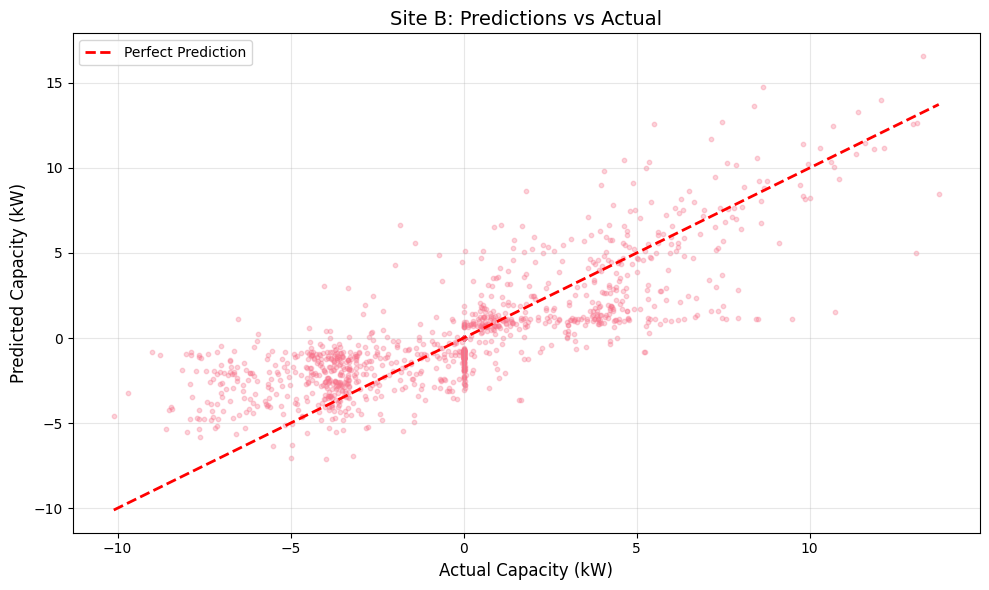

In [25]:
# Scatter plot: Predictions vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(targets, predictions_corrected, alpha=0.3, s=10)
plt.plot([targets.min(), targets.max()], [targets.min(), targets.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Capacity (kW)', fontsize=12)
plt.ylabel('Predicted Capacity (kW)', fontsize=12)
plt.title('Site B: Predictions vs Actual', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

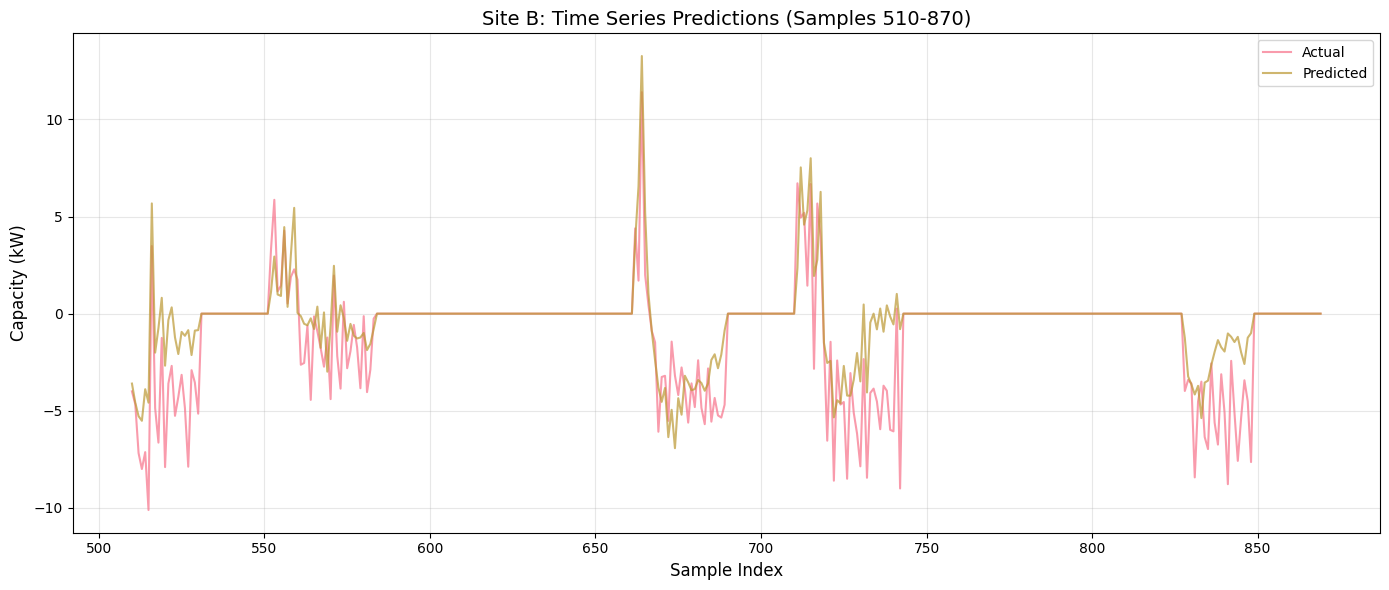

In [26]:
zoomed = 1

if zoomed == 0: # Zoomed out view
    sample_start = 500
    sample_end = 3000
elif zoomed == 1: # Zoomed in on several events
    sample_start = 510
    sample_end = 870
elif zoomed == 2: # 2 load shift cases
    sample_start = 510
    sample_end = 600
elif zoomed == 3: # 1 DR=+1 case and 1 load shift case
    sample_start = 1100
    sample_end = 1200
elif zoomed == 4: # 2 DR=+1 cases
    sample_start = 1840
    sample_end = 1980

plt.figure(figsize=(14, 6))
x = np.arange(sample_start, min(sample_end, len(targets)))
plt.plot(x, targets[sample_start:sample_end], label='Actual', alpha=0.7, linewidth=1.5)
plt.plot(x, predictions_corrected[sample_start:sample_end], label='Predicted', alpha=0.7, linewidth=1.5)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Capacity (kW)', fontsize=12)
plt.title(f'Site B: Time Series Predictions (Samples {sample_start}-{sample_end})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
print(targets[600])
print(predictions[600])

0.0
-0.056857422


In [28]:
# After masking
df_val_masked = df_train_site_b[mask_site_b].reset_index(drop=True)

# Align with sequences
df_val_aligned = df_val_masked.iloc[sequence_length:sequence_length + len(predictions)].reset_index(drop=True)

# Check DR flags at sample 675
sample_index = 675
dr_flags = df_val_aligned.loc[sample_index, ['Demand_Response_Flag_-1', 'Demand_Response_Flag_0', 'Demand_Response_Flag_1']]
print(dr_flags)

if dr_flags['Demand_Response_Flag_1'] == 1:
    print("✅ There is a DR event at sample 675")
else:
    print("❌ No DR event at sample 675")


Demand_Response_Flag_-1     True
Demand_Response_Flag_0     False
Demand_Response_Flag_1     False
Name: 675, dtype: object
❌ No DR event at sample 675


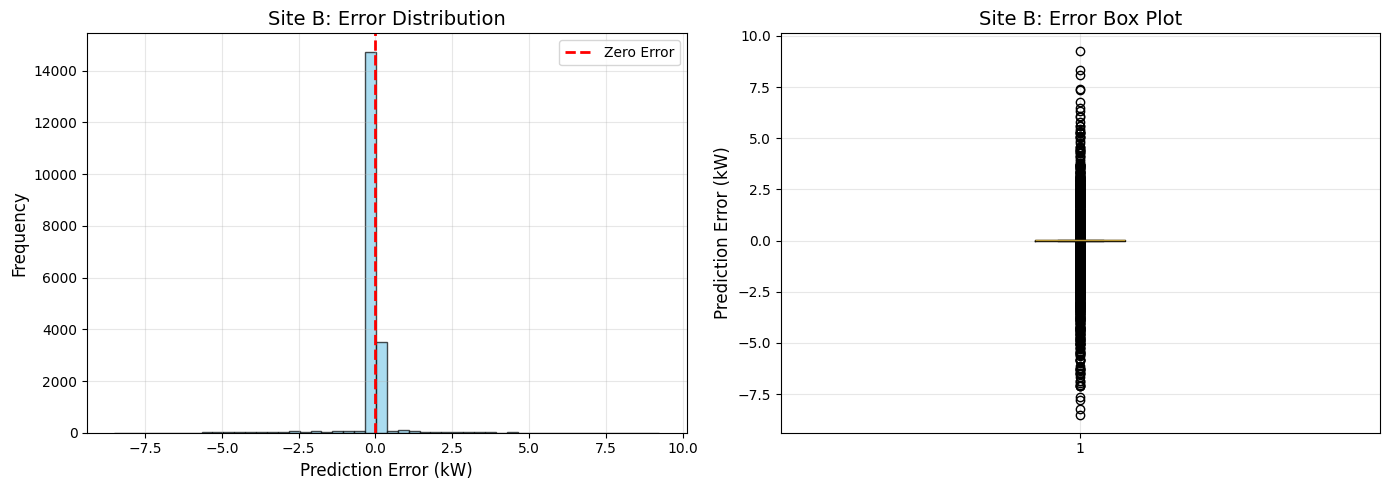

Error Statistics:
  Mean Error: -0.0162 kW
  Std Error: 0.6146 kW
  Min Error: -8.4966 kW
  Max Error: 9.2375 kW


In [29]:
# Error distribution
errors = targets - predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(errors, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_xlabel('Prediction Error (kW)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Site B: Error Distribution', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(errors, vert=True)
axes[1].set_ylabel('Prediction Error (kW)', fontsize=12)
axes[1].set_title('Site B: Error Box Plot', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Error Statistics:")
print(f"  Mean Error: {errors.mean():.4f} kW")
print(f"  Std Error: {errors.std():.4f} kW")
print(f"  Min Error: {errors.min():.4f} kW")
print(f"  Max Error: {errors.max():.4f} kW")

## 9. Additional Analysis

In [30]:
# Analyze by demand response flag
print("\nPerformance by Demand Response Flag:")
print("=" * 60)
for flag in [-1, 0, 1]:
    mask = val_demand_flags == flag
    if mask.sum() > 0:
        flag_mae = np.abs(targets[mask] - predictions[mask]).mean()
        flag_rmse = np.sqrt(np.mean((targets[mask] - predictions[mask]) ** 2))
        print(f"Flag {flag:2d}: {mask.sum():5d} samples | MAE = {flag_mae:7.4f} kW | RMSE = {flag_rmse:7.4f} kW")


Performance by Demand Response Flag:
Flag -1:   676 samples | MAE =  1.9919 kW | RMSE =  2.4846 kW
Flag  0: 18135 samples | MAE =  0.0154 kW | RMSE =  0.0598 kW
Flag  1:   433 samples | MAE =  1.9447 kW | RMSE =  2.6480 kW


In [31]:
# Find worst predictions
abs_errors = np.abs(targets - predictions)
worst_indices = np.argsort(abs_errors)[-10:][::-1]

print("\nTop 10 Worst Predictions (Site B):")
print("=" * 80)
for idx in worst_indices:
    print(f"Index {idx:5d}: Actual={targets[idx]:7.2f} kW | Predicted={predictions[idx]:7.2f} kW | Error={abs_errors[idx]:7.2f} kW")


Top 10 Worst Predictions (Site B):
Index  1853: Actual=  10.74 kW | Predicted=   1.50 kW | Error=   9.24 kW
Index  1847: Actual=  -1.83 kW | Predicted=   6.67 kW | Error=   8.50 kW
Index  2862: Actual=   9.48 kW | Predicted=   1.14 kW | Error=   8.34 kW
Index   742: Actual=  -9.00 kW | Predicted=  -0.80 kW | Error=   8.20 kW
Index  2858: Actual=  13.07 kW | Predicted=   4.99 kW | Error=   8.08 kW
Index   841: Actual=  -8.78 kW | Predicted=  -1.02 kW | Error=   7.76 kW
Index 18043: Actual=  -6.53 kW | Predicted=   1.11 kW | Error=   7.64 kW
Index  1959: Actual=   8.51 kW | Predicted=   1.12 kW | Error=   7.39 kW
Index  8268: Actual=   8.44 kW | Predicted=   1.11 kW | Error=   7.33 kW
Index 18593: Actual=  -4.03 kW | Predicted=   3.08 kW | Error=   7.11 kW


## 10. Summary

In [32]:
print("\n" + "=" * 80)
print("EVALUATION SUMMARY - SITE B")
print("=" * 80)

print(f"\nModel: {MODEL_CHECKPOINT}")
print(f"\nValidation Site: Site B")
print(f"Validation Samples: {len(predictions)}")
print(f"\nKey Metrics:")
print(f"  • NMAE (mean): {metrics['nmae_mean']:.2f}%")
print(f"  • NRMSE (mean): {metrics['nrmse_mean']:.2f}%")
print(f"  • MAE: {mae:.4f} kW")
print(f"  • RMSE: {rmse:.4f} kW")
print(f"  • F1 Score: {metrics['f1_score']:.4f}")
print(f"  • R² Score: {r2:.4f}")
print(f"  • Prediction Std: {predictions.std():.4f} kW")

if predictions.std() < 1.0:
    print(f"\n⚠️  WARNING: Model produces nearly horizontal predictions!")
elif metrics['nmae_mean'] < 30:
    print(f"\n✅ Model performance looks good on Site B!")
elif metrics['nmae_mean'] < 40:
    print(f"\n🔶 Model performance is acceptable on Site B, but could be improved.")
else:
    print(f"\n❌ Model performance needs improvement on Site B.")
    
print("=" * 80)


EVALUATION SUMMARY - SITE B

Model: ../notebooks/wandb/run-20251207_215841-3jlrrzpq/files/best_model.pt

Validation Site: Site B
Validation Samples: 19244

Key Metrics:
  • NMAE (mean): 1.64%
  • NRMSE (mean): 8.81%
  • MAE: 0.1282 kW
  • RMSE: 0.6148 kW
  • F1 Score: 0.9565
  • R² Score: 0.6408
  • Prediction Std: 0.8446 kW

⚠️  WARNING: Model produces nearly horizontal predictions!
